# Flight Delay Data Cleaning

This notebook performs Steps 1-7 of the flight delay pipeline:
- Load and inspect raw datasets
- Analyze numeric ranges
- Optimize dtypes for large-file efficiency
- Clean invalid records and engineer key features
- Save `cleaned_data.csv`

## Step 0 - Imports and Runtime Settings

In [39]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display

# Helps reduce copy overhead for large DataFrames.
pd.options.mode.copy_on_write = True

/var/folders/mb/xcn1fzjx76ndcb617gpnmf3c0000gn/T/ipykernel_90630/1684985651.py:7: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


## Step 1 - Configuration Paths

In [40]:
ROOT = Path.cwd()
if not (ROOT / "data/raw/flights.csv").exists() and (ROOT.parent / "data/raw/flights.csv").exists():
    ROOT = ROOT.parent

flights_path = ROOT / "data/raw/flights.csv"
airports_path = ROOT / "data/raw/airports.csv"
airlines_path = ROOT / "data/raw/airlines.csv"

cleaned_output = ROOT / "data/processed/cleaned_data.csv"
merged_output = ROOT / "data/processed/merged_data.csv"

print("Using root:", ROOT)

Using root: /Users/adityasingh/DV


## Step 2 - Constants and Helper Functions

In [41]:
NUMERIC_COLUMNS = [
    "YEAR", "MONTH", "DAY", "DAY_OF_WEEK", "FLIGHT_NUMBER",
    "SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "DEPARTURE_DELAY",
    "TAXI_OUT", "WHEELS_OFF", "SCHEDULED_TIME", "ELAPSED_TIME",
    "AIR_TIME", "DISTANCE", "WHEELS_ON", "TAXI_IN",
    "SCHEDULED_ARRIVAL", "ARRIVAL_TIME", "ARRIVAL_DELAY",
    "DIVERTED", "CANCELLED", "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY",
]

def memory_usage_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / (1024 ** 2)

def print_section(title: str) -> None:
    print(f"\n{'=' * 20} {title} {'=' * 20}")

## Step 3 - Load Datasets

In [42]:
flights = pd.read_csv(flights_path, low_memory=False)
airports = pd.read_csv(airports_path, low_memory=False)
airlines = pd.read_csv(airlines_path, low_memory=False)

print_section("STEP 1 - Load Datasets")
print("Flights :", flights.shape)
print("Airports:", airports.shape)
print("Airlines:", airlines.shape)


==================== STEP 1 - Load Datasets ====================
Flights : (5993651, 31)
Airports: (322, 7)
Airlines: (14, 2)


## Step 4 - Dataset Inspection

In [43]:
print_section("STEP 2 - Flights Inspection")

print("Columns:")
print(flights.columns.tolist())

print("\nFirst 5 rows:")
display(flights.head())

print("\nMissing values:")
display(flights.isna().sum().sort_values(ascending=False))

print("\nData types:")
display(flights.dtypes)


==================== STEP 2 - Flights Inspection ====================
Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

First 5 rows:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,anc,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,aa,2336,N3KUAA,Lax,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,us,840,N171US,sfo,clt,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,Aa,258,N3HYAA,LAX,mia,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,Sea,anc,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN



Missing values:


CANCELLATION_REASON    5901058
WEATHER_DELAY          4898362
LATE_AIRCRAFT_DELAY    4898362
AIRLINE_DELAY          4898362
SECURITY_DELAY         4898362
AIR_SYSTEM_DELAY       4898362
ARRIVAL_DELAY           407897
AIR_TIME                407897
DEPARTURE_DELAY         388428
DISTANCE                299682
ELAPSED_TIME            108215
ARRIVAL_TIME             95296
WHEELS_ON                95296
TAXI_IN                  95296
WHEELS_OFF               91741
TAXI_OUT                 91741
DEPARTURE_TIME           88746
TAIL_NUMBER              15184
SCHEDULED_TIME               6
DESTINATION_AIRPORT          0
SCHEDULED_DEPARTURE          0
MONTH                        0
SCHEDULED_ARRIVAL            0
ORIGIN_AIRPORT               0
DIVERTED                     0
CANCELLED                    0
FLIGHT_NUMBER                0
AIRLINE                      0
DAY_OF_WEEK                  0
DAY                          0
YEAR                         0
dtype: int64


Data types:


YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                    str
FLIGHT_NUMBER            int64
TAIL_NUMBER                str
ORIGIN_AIRPORT             str
DESTINATION_AIRPORT        str
SCHEDULED_DEPARTURE      int64
DEPARTURE_TIME         float64
DEPARTURE_DELAY        float64
TAXI_OUT               float64
WHEELS_OFF             float64
SCHEDULED_TIME         float64
ELAPSED_TIME           float64
AIR_TIME               float64
DISTANCE               float64
WHEELS_ON              float64
TAXI_IN                float64
SCHEDULED_ARRIVAL        int64
ARRIVAL_TIME           float64
ARRIVAL_DELAY          float64
DIVERTED                 int64
CANCELLED                int64
CANCELLATION_REASON        str
AIR_SYSTEM_DELAY       float64
SECURITY_DELAY         float64
AIRLINE_DELAY          float64
LATE_AIRCRAFT_DELAY    float64
WEATHER_DELAY          float64
dtype: object

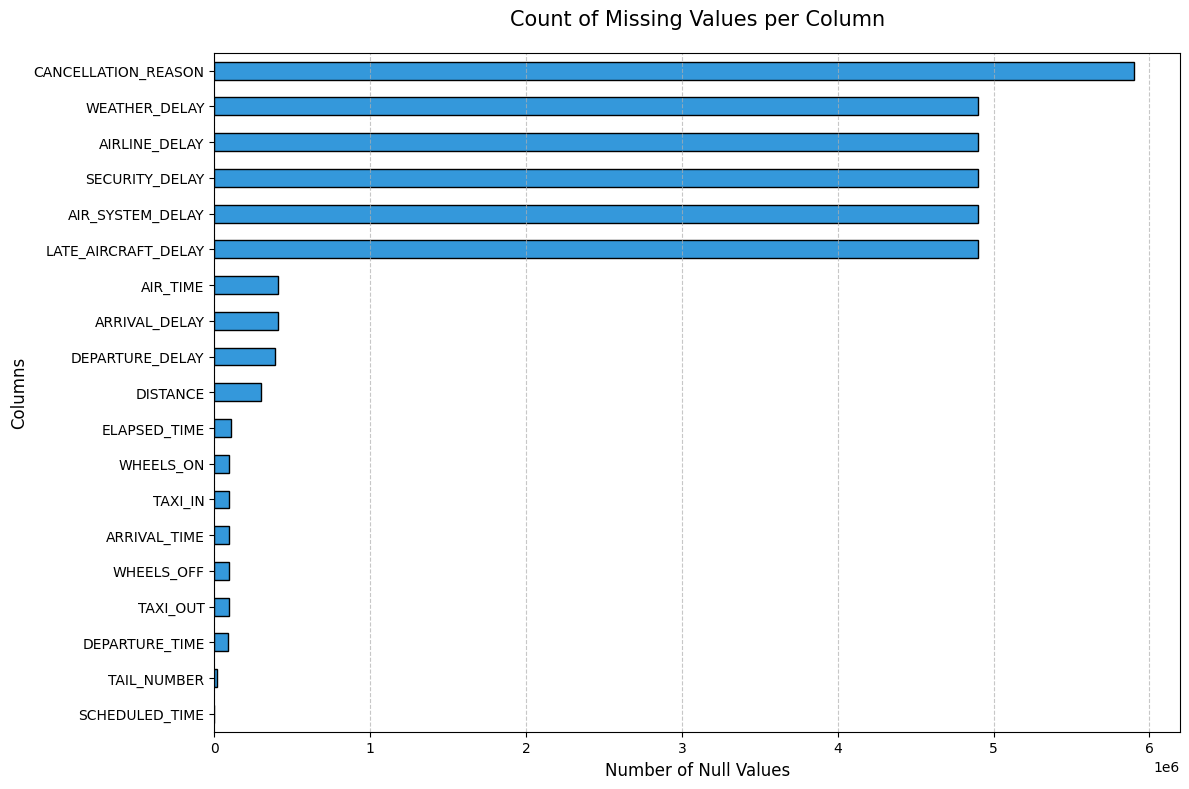

In [44]:
import matplotlib.pyplot as plt

null_counts = flights.isna().sum()
# Only plot columns that have missing values
missing_data = null_counts[null_counts > 0].sort_values()

if not missing_data.empty:
    plt.figure(figsize=(12, 8))
    missing_data.plot(kind='barh', color='#3498db', edgecolor='black')
    plt.title('Count of Missing Values per Column', fontsize=15, pad=20)
    plt.xlabel('Number of Null Values', fontsize=12)
    plt.ylabel('Columns', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset.")


## Step 5 - Numeric Conversion and Range Analysis

In [45]:
for col in NUMERIC_COLUMNS:
    if col in flights.columns:
        flights[col] = pd.to_numeric(flights[col], errors="coerce")

numeric_cols = flights.select_dtypes(include=[np.number]).columns

range_table = pd.DataFrame({
    "Column": numeric_cols,
    "Min": [flights[c].min() for c in numeric_cols],
    "Max": [flights[c].max() for c in numeric_cols],
})

print_section("STEP 3 - Numeric Column Range Analysis")
display(range_table.sort_values("Column").reset_index(drop=True))


==================== STEP 3 - Numeric Column Range Analysis ====================


,Column,Min,Max
0,AIRLINE_DELAY,0.0,1971.0
1,AIR_SYSTEM_DELAY,0.0,1134.0
2,AIR_TIME,7.0,690.0
3,ARRIVAL_DELAY,-87.0,1898.0
4,ARRIVAL_TIME,1.0,2400.0
5,CANCELLED,0.0,1.0
6,DAY,1.0,31.0
7,DAY_OF_WEEK,1.0,7.0
8,DEPARTURE_DELAY,-82.0,1988.0
9,DEPARTURE_TIME,1.0,2400.0


## Step 6 - Data Type Optimization

Memory before: 2589.07 MB
Memory after : 1863.14 MB


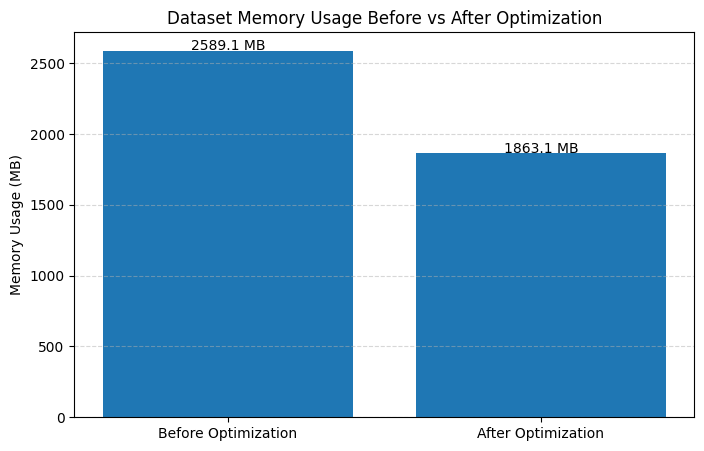

Memory reduced by 28.04%


In [46]:
import seaborn as sns

before = memory_usage_mb(flights)

for col in flights.select_dtypes(include=[np.number]).columns:
    s = flights[col]
    non_null = s.dropna()

    if non_null.empty:
        continue

    # Check if values are integer-like
    is_int_like = np.isclose(non_null, np.floor(non_null)).all()

    if is_int_like and not s.isna().any():
        flights[col] = pd.to_numeric(s, downcast="integer")
    else:
        flights[col] = pd.to_numeric(s, downcast="float")

after = memory_usage_mb(flights)

print(f"Memory before: {before:.2f} MB")
print(f"Memory after : {after:.2f} MB")

memory_df = pd.DataFrame({
    "Stage": ["Before Optimization", "After Optimization"],
    "Memory_MB": [before, after]
})

plt.figure(figsize=(8,5))

bars = plt.bar(memory_df["Stage"], memory_df["Memory_MB"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 5,
             f"{height:.1f} MB",
             ha='center')

plt.title("Dataset Memory Usage Before vs After Optimization")
plt.ylabel("Memory Usage (MB)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# Optional: print reduction percentage
reduction = ((before - after) / before) * 100
print(f"Memory reduced by {reduction:.2f}%")

## Step 7 - Data Cleaning and Feature Engineering

Cleaned shape: (5667205, 31)

==================== Visualization - Delay Heatmap (Operated Flights Only) ====================


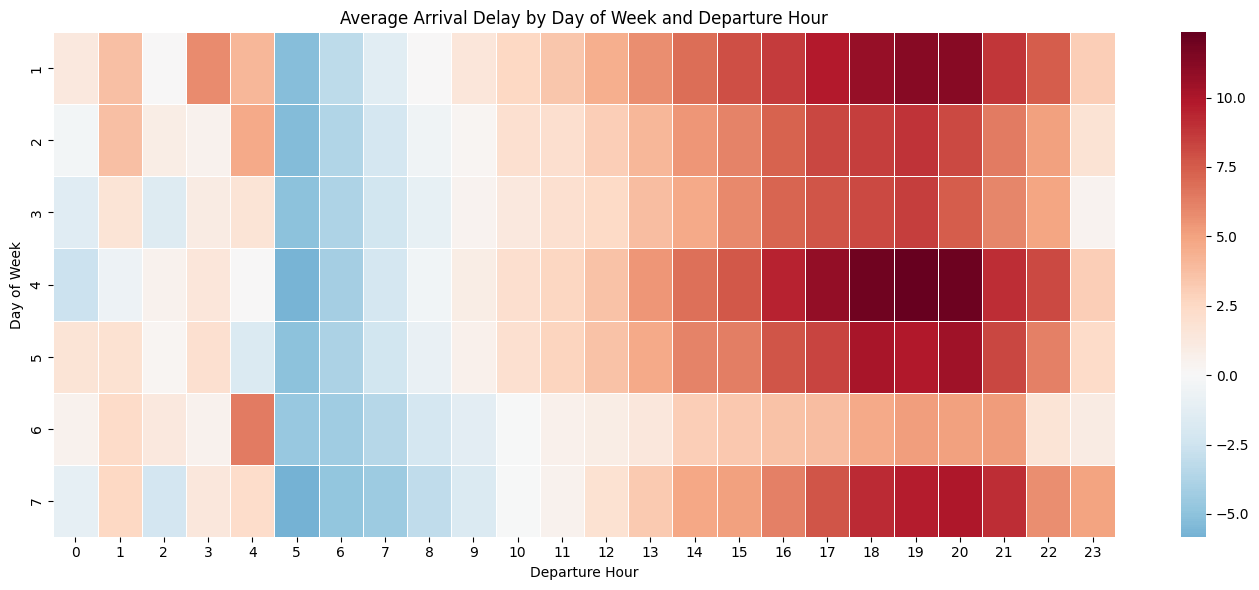

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Keep cancelled flights in cleaned output.
# Only apply ARRIVAL_DELAY quality filtering to operated flights.
cleaned = flights.copy()

cleaned["AIRLINE"] = cleaned["AIRLINE"].astype(str).str.strip().str.upper()
cleaned["ORIGIN_AIRPORT"] = cleaned["ORIGIN_AIRPORT"].astype(str).str.strip().str.upper()
cleaned["DESTINATION_AIRPORT"] = cleaned["DESTINATION_AIRPORT"].astype(str).str.strip().str.upper()

# Preserve cancellations; filter unrealistic ARRIVAL_DELAY only for non-cancelled flights
valid_operated = (
    (cleaned["CANCELLED"] == 0)
    & cleaned["ARRIVAL_DELAY"].notna()
    & cleaned["ARRIVAL_DELAY"].between(-60, 300)
)
keep_cancelled = cleaned["CANCELLED"] == 1
cleaned = cleaned.loc[valid_operated | keep_cancelled].copy()

print("Cleaned shape:", cleaned.shape)

cleaned["scheduled_dep_hour"] = (cleaned["SCHEDULED_DEPARTURE"] // 100).clip(0, 23).astype("int8")
cleaned["route"] = cleaned["ORIGIN_AIRPORT"] + "-" + cleaned["DESTINATION_AIRPORT"]

# Add explicit cancelled class so downstream analyses can include/exclude intentionally
cleaned["delay_severity"] = np.select(
    [
        cleaned["CANCELLED"] == 1,
        cleaned["ARRIVAL_DELAY"] < 15,
        cleaned["ARRIVAL_DELAY"].between(15, 60, inclusive="both"),
    ],
    ["Cancelled", "Minor", "Moderate"],
    default="Severe",
)
cleaned["delay_severity"] = pd.Categorical(
    cleaned["delay_severity"],
    categories=["Cancelled", "Minor", "Moderate", "Severe"],
    ordered=True,
)

print_section("Visualization - Delay Heatmap (Operated Flights Only)")

# Heatmap only for non-cancelled operated flights
heatmap_base = cleaned.loc[cleaned["CANCELLED"] == 0].copy()
heatmap_data = heatmap_base.pivot_table(
    values="ARRIVAL_DELAY",
    index="DAY_OF_WEEK",
    columns="scheduled_dep_hour",
    aggfunc="mean"
)

plt.figure(figsize=(14,6))
sns.heatmap(
    heatmap_data,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.title("Average Arrival Delay by Day of Week and Departure Hour")
plt.xlabel("Departure Hour")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()



## Step 8 - Save Cleaned Dataset and Quick Verification

In [48]:
cleaned.to_csv(cleaned_output, index=False)

print_section("STEP 7 - Saved Cleaned Dataset")
print("Saved:", cleaned_output)

print_section("Verification")
print("Cleaned shape:", cleaned.shape)
print(f"Cleaned memory usage: {memory_usage_mb(cleaned):.2f} MB")
display(cleaned.head())


==================== STEP 7 - Saved Cleaned Dataset ====================
Saved: /Users/adityasingh/DV/data/processed/cleaned_data.csv

==================== Verification ====================
Cleaned shape: (5667205, 34)
Cleaned memory usage: 2107.27 MB


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,scheduled_dep_hour,route,delay_severity
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,ANC-SEA,Minor
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,LAX-PBI,Minor
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,SFO-CLT,Minor
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,LAX-MIA,Minor
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,0,NaN,NaN,NaN,NaN,NaN,NaN,0,SEA-ANC,Minor
